# 第141章: JEPA — Joint Embedding Predictive Architecture

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] I-JEPAの非対称マスキング戦略を設計・実装できる
- [ ] Context Encoder / Target Encoder / Predictor の役割を説明できる
- [ ] EMA（指数移動平均）更新の仕組みと崩壊防止効果を理解できる
- [ ] MAE（ピクセル再構成）との本質的な違いを議論できる
- [ ] V-JEPA（動画版）への拡張の考え方を説明できる

## 🎯 前提知識

- ✅ Notebook 140（世界モデル概論）
- ✅ Notebook 95（Vision Transformer / Self-Attention）
- ✅ Notebook 130（時間的注意機構の基礎）

⏱️ **推定学習時間**: 150-180分
📊 **難易度**: ★★★★☆（上級）
🎓 **カテゴリ**: 世界モデル / 自己教師あり学習

## 目次

1. [JEPAの思想 — なぜピクセル再構成ではダメなのか](#section1)
2. [I-JEPA アーキテクチャの解剖](#section2)
3. [MultiBlockMasking の実装](#section3)
4. [エンコーダとプレディクタの実装](#section4)
5. [EMA更新の実装と理解](#section5)
6. [I-JEPA訓練ループ](#section6)
7. [学習済み表現の評価](#section7)
8. [V-JEPAへの拡張（概念）](#section8)
9. [まとめとよくあるエラー](#summary)
10. [自己評価クイズ](#quiz)

In [1]:
# ============================================================
# 環境設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import copy
import math
import warnings

warnings.filterwarnings('ignore')

# 日本語フォント設定
def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 再現性の確保
torch.manual_seed(42)
np.random.seed(42)

# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'✅ ライブラリのインポート完了')
print(f'🖥️ デバイス: {device}')
print(f'📝 日本語フォント: {font_used}')

✅ ライブラリのインポート完了
🖥️ デバイス: cpu
📝 日本語フォント: Yu Gothic


<a id="section1"></a>
## 1. JEPAの思想 — なぜピクセル再構成ではダメなのか

### 🤔 自己教師あり学習の2つのアプローチ

自己教師あり学習（Self-Supervised Learning）では、ラベルなしデータから有用な表現を学習します。
代表的なアプローチは以下の2つです：

| アプローチ | 代表手法 | 予測対象 | 問題点 |
|-----------|---------|---------|--------|
| **再構成ベース** | MAE, BEiT | ピクセル値 / トークン | 低レベルのディテールに注力 |
| **埋め込みベース** | JEPA, BYOL | 潜在表現 | 表現崩壊のリスク |

**MAE（Masked Autoencoder）** は画像のパッチをマスクし、そのピクセル値を再構成します。
しかし、ピクセルの再構成は「テクスチャの再現」に多くの容量を使ってしまい、
**意味的な理解**（物体の形状、関係性など）の学習が非効率になります。

**JEPA** はYann LeCunが提唱した「A Path Towards Autonomous Machine Intelligence」の
中核概念で、**ピクセルではなく埋め込み空間で予測する** ことで、
意味的に豊かな表現を効率的に学習します。

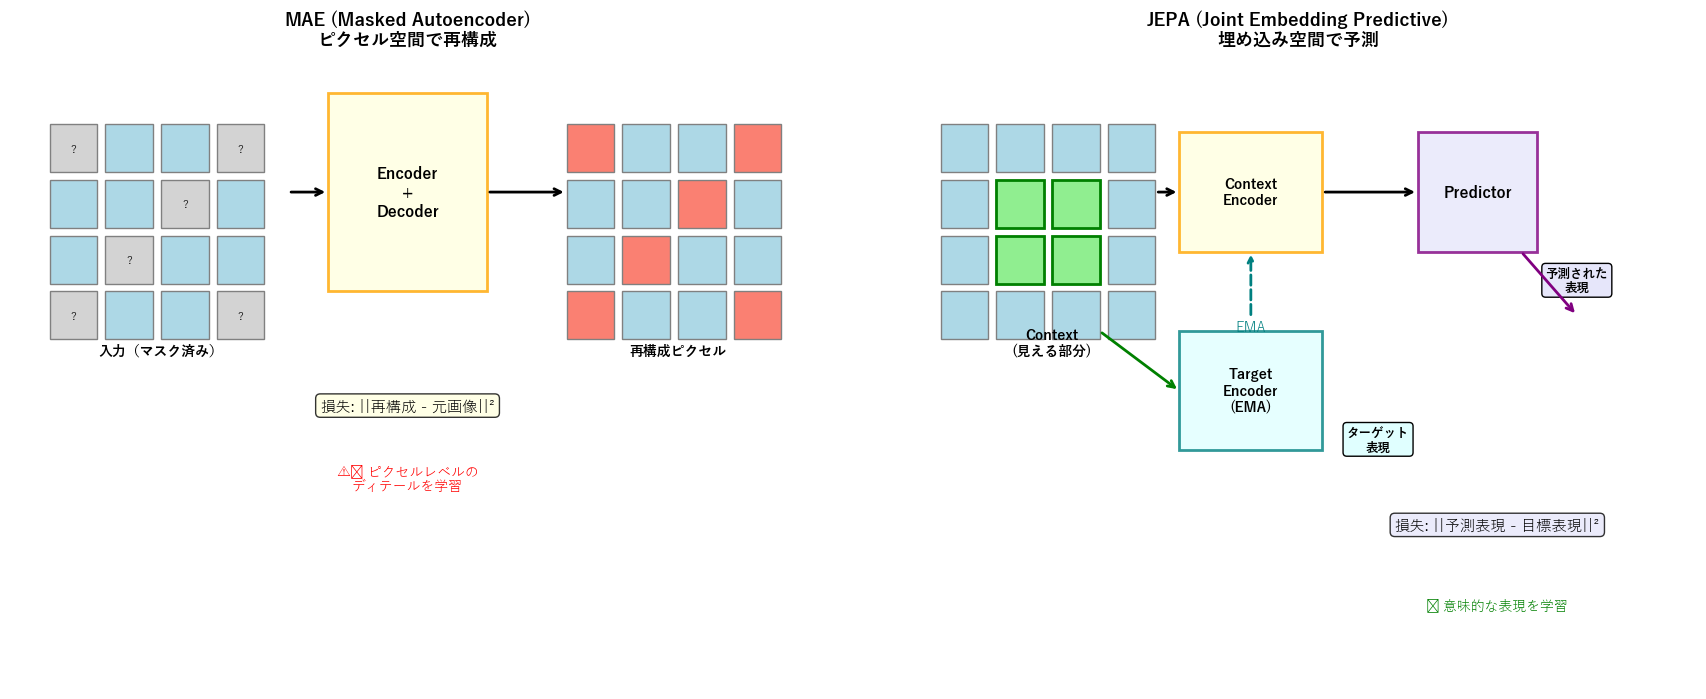

In [2]:
# ============================================================
# MAE vs JEPA アーキテクチャ比較図
# ============================================================

def visualize_mae_vs_jepa():
    """MAEとJEPAのアーキテクチャ比較を図示"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- MAE (左) ---
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('MAE (Masked Autoencoder)\nピクセル空間で再構成', fontsize=13, fontweight='bold')

    # 入力画像（マスクあり）
    for i in range(4):
        for j in range(4):
            color = 'lightblue' if not ((i+j) % 3 == 0) else 'lightgray'
            label = '?' if (i+j) % 3 == 0 else ''
            rect = plt.Rectangle((0.5 + j*0.7, 6.5 - i*0.7), 0.6, 0.6,
                                  facecolor=color, edgecolor='gray')
            ax.add_patch(rect)
            if label:
                ax.text(0.8 + j*0.7, 6.8 - i*0.7, label, ha='center', va='center', fontsize=8)

    ax.text(1.9, 4.2, '入力（マスク済み）', ha='center', fontsize=10, fontweight='bold')

    # Encoder
    rect = plt.Rectangle((4.0, 5.0), 2.0, 2.5, facecolor='lightyellow',
                          edgecolor='orange', linewidth=2, alpha=0.8)
    ax.add_patch(rect)
    ax.text(5.0, 6.25, 'Encoder\n+\nDecoder', ha='center', va='center', fontsize=11, fontweight='bold')

    # 矢印
    ax.annotate('', xy=(4.0, 6.25), xytext=(3.5, 6.25),
                arrowprops=dict(arrowstyle='->', lw=2))

    # 出力（ピクセル再構成）
    for i in range(4):
        for j in range(4):
            color = 'salmon' if (i+j) % 3 == 0 else 'lightblue'
            rect = plt.Rectangle((7.0 + j*0.7, 6.5 - i*0.7), 0.6, 0.6,
                                  facecolor=color, edgecolor='gray')
            ax.add_patch(rect)
    ax.text(8.4, 4.2, '再構成ピクセル', ha='center', fontsize=10, fontweight='bold')
    ax.annotate('', xy=(7.0, 6.25), xytext=(6.0, 6.25),
                arrowprops=dict(arrowstyle='->', lw=2))

    # 損失
    ax.text(5.0, 3.5, '損失: ||再構成 - 元画像||²', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.text(5.0, 2.5, '⚠️ ピクセルレベルの\nディテールを学習', ha='center', fontsize=10, color='red')

    # --- JEPA (右) ---
    ax = axes[1]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('JEPA (Joint Embedding Predictive)\n埋め込み空間で予測', fontsize=13, fontweight='bold')

    # Context patches
    for i in range(4):
        for j in range(4):
            color = 'lightblue' if not ((i >= 1 and i <= 2) and (j >= 1 and j <= 2)) else 'lightgray'
            rect = plt.Rectangle((0.5 + j*0.7, 6.5 - i*0.7), 0.6, 0.6,
                                  facecolor=color, edgecolor='gray')
            ax.add_patch(rect)
    ax.text(1.9, 4.2, 'Context\n(見える部分)', ha='center', fontsize=10, fontweight='bold')

    # Target patches
    for i in range(2):
        for j in range(2):
            rect = plt.Rectangle((0.5 + (j+1)*0.7, 6.5 - (i+1)*0.7), 0.6, 0.6,
                                  facecolor='lightgreen', edgecolor='green', linewidth=2)
            ax.add_patch(rect)

    # Context Encoder
    rect1 = plt.Rectangle((3.5, 5.5), 1.8, 1.5, facecolor='lightyellow',
                           edgecolor='orange', linewidth=2, alpha=0.8)
    ax.add_patch(rect1)
    ax.text(4.4, 6.25, 'Context\nEncoder', ha='center', va='center', fontsize=10, fontweight='bold')

    # Target Encoder
    rect2 = plt.Rectangle((3.5, 3.0), 1.8, 1.5, facecolor='lightcyan',
                           edgecolor='teal', linewidth=2, alpha=0.8)
    ax.add_patch(rect2)
    ax.text(4.4, 3.75, 'Target\nEncoder\n(EMA)', ha='center', va='center', fontsize=10, fontweight='bold')

    # Predictor
    rect3 = plt.Rectangle((6.5, 5.5), 1.5, 1.5, facecolor='lavender',
                           edgecolor='purple', linewidth=2, alpha=0.8)
    ax.add_patch(rect3)
    ax.text(7.25, 6.25, 'Predictor', ha='center', va='center', fontsize=11, fontweight='bold')

    # 矢印
    ax.annotate('', xy=(3.5, 6.25), xytext=(3.2, 6.25),
                arrowprops=dict(arrowstyle='->', lw=2))
    ax.annotate('', xy=(6.5, 6.25), xytext=(5.3, 6.25),
                arrowprops=dict(arrowstyle='->', lw=2))
    ax.annotate('', xy=(3.5, 3.75), xytext=(2.5, 4.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))

    # 予測と目標の比較
    ax.text(8.5, 5.0, '予測された\n表現', ha='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lavender'))
    ax.text(6.0, 3.0, 'ターゲット\n表現', ha='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightcyan'))

    ax.annotate('', xy=(8.5, 4.7), xytext=(7.8, 5.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='purple'))

    # 損失
    ax.text(7.5, 2.0, '損失: ||予測表現 - 目標表現||²', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))
    ax.text(7.5, 1.0, '✅ 意味的な表現を学習', ha='center', fontsize=10, color='green')

    # EMA矢印
    ax.annotate('EMA', xy=(4.4, 5.5), xytext=(4.4, 4.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='teal', linestyle='--'),
                ha='center', fontsize=10, color='teal')

    plt.tight_layout()
    plt.show()

visualize_mae_vs_jepa()

### 💡 ピクセル再構成の問題点を直感的に理解する

**例**: 犬の画像の一部がマスクされているとします。

- **MAEの予測**: マスク部分のピクセル値（毛の色、テクスチャ、光の反射など）を正確に再現
- **JEPAの予測**: マスク部分の**意味的な表現**（「ここには犬の耳がある」という抽象的情報）を予測

MAEは「ピクセルの色」を当てるのに計算資源を使いますが、
JEPAは「何があるか」という**高レベルの意味**を学習します。

> **Yann LeCun の主張**: 「世界のモデルを構築するには、ピクセルレベルの詳細ではなく、
> 抽象的な表現レベルでの予測が必要である。なぜなら、現実世界の多くの詳細は
> 予測不可能であり、予測する必要もないからである。」

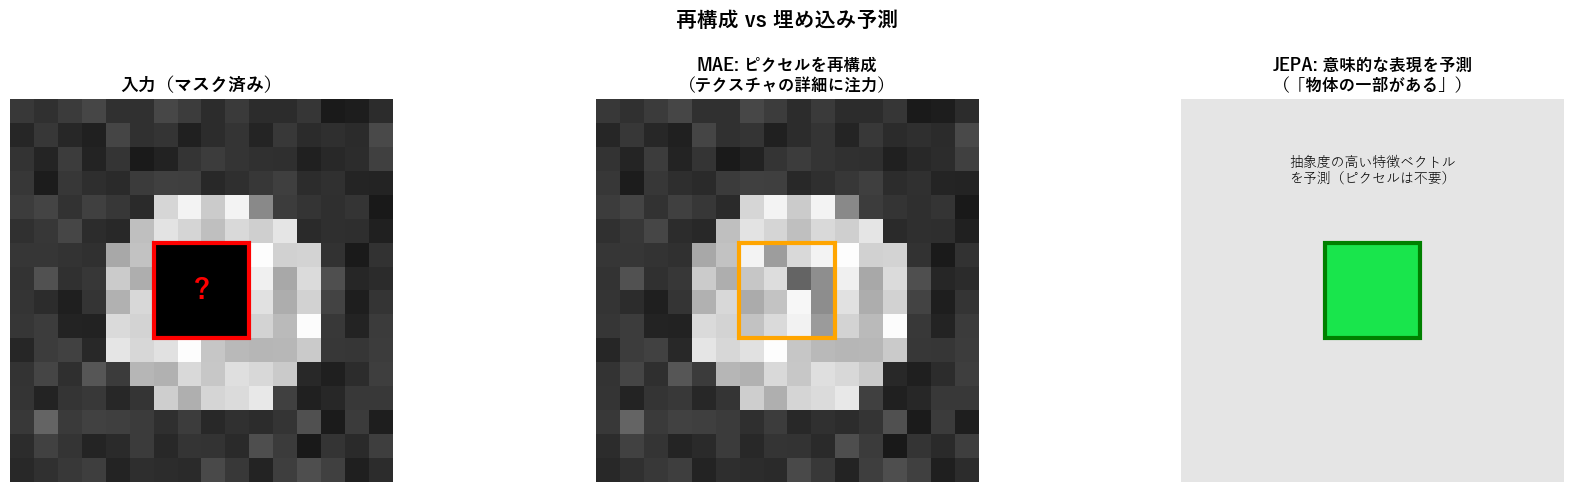

In [3]:
# ============================================================
# ピクセル再構成 vs 埋め込み予測の違いを可視化
# ============================================================

def demonstrate_pixel_vs_embedding():
    """ピクセル空間と埋め込み空間での予測の違いを図示"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 元画像（合成）
    np.random.seed(42)
    img = np.zeros((16, 16))
    # 丸い物体を描画
    for i in range(16):
        for j in range(16):
            if (i - 8)**2 + (j - 8)**2 < 25:
                img[i, j] = 0.8 + np.random.randn() * 0.1
            else:
                img[i, j] = 0.2 + np.random.randn() * 0.05

    # マスク（中央4x4）
    mask = np.ones((16, 16))
    mask[6:10, 6:10] = 0

    ax = axes[0]
    ax.imshow(img * mask, cmap='gray', vmin=0, vmax=1)
    ax.add_patch(plt.Rectangle((5.5, 5.5), 4, 4, fill=False, edgecolor='red', linewidth=3))
    ax.set_title('入力（マスク済み）', fontsize=13, fontweight='bold')
    ax.text(7.5, 7.5, '?', ha='center', va='center', fontsize=20, color='red', fontweight='bold')
    ax.axis('off')

    # MAEの予測: ピクセル値を再構成
    ax = axes[1]
    mae_pred = img.copy()
    # ピクセル再構成にはノイズが含まれる
    mae_pred[6:10, 6:10] = img[6:10, 6:10] + np.random.randn(4, 4) * 0.15
    ax.imshow(mae_pred, cmap='gray', vmin=0, vmax=1)
    ax.add_patch(plt.Rectangle((5.5, 5.5), 4, 4, fill=False, edgecolor='orange', linewidth=3))
    ax.set_title('MAE: ピクセルを再構成\n（テクスチャの詳細に注力）', fontsize=12, fontweight='bold')
    ax.axis('off')

    # JEPAの予測: 抽象的な表現
    ax = axes[2]
    # 意味的な情報のヒートマップ
    semantic_map = np.zeros((4, 4))
    for i in range(4):
        for j in range(4):
            ci, cj = i + 6, j + 6
            if (ci - 8)**2 + (cj - 8)**2 < 25:
                semantic_map[i, j] = 0.9  # 物体の一部
            else:
                semantic_map[i, j] = 0.1  # 背景

    display = np.zeros((16, 16, 3))
    display[:, :, 0] = 0.9
    display[:, :, 1] = 0.9
    display[:, :, 2] = 0.9
    for i in range(4):
        for j in range(4):
            v = semantic_map[i, j]
            display[6+i, 6+j] = [1.0 - v, v, 0.3]  # 高い=緑, 低い=赤
    ax.imshow(display)
    ax.add_patch(plt.Rectangle((5.5, 5.5), 4, 4, fill=False, edgecolor='green', linewidth=3))
    ax.set_title('JEPA: 意味的な表現を予測\n（「物体の一部がある」）', fontsize=12, fontweight='bold')
    ax.text(7.5, 3.0, '抽象度の高い特徴ベクトル\nを予測（ピクセルは不要）', ha='center', fontsize=10)
    ax.axis('off')

    plt.suptitle('再構成 vs 埋め込み予測', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

demonstrate_pixel_vs_embedding()

<a id="section2"></a>
## 2. I-JEPA アーキテクチャの解剖

### 📊 3つのコンポーネント

I-JEPA（Image-based JEPA）は3つの主要コンポーネントで構成されます：

| コンポーネント | 役割 | 更新方法 |
|---------------|------|---------|
| **Context Encoder** ($f_\\theta$) | 可視パッチをエンコード | 勾配降下（通常の学習） |
| **Target Encoder** ($f_\\bar{\\theta}$) | ターゲットパッチをエンコード | EMA（Context Encoderの移動平均） |
| **Predictor** ($g_\\phi$) | Context表現からTarget表現を予測 | 勾配降下（通常の学習） |

### 🔑 非対称マスキング戦略

I-JEPAの独自の工夫は**非対称マスキング**です：
- **Context（コンテキスト）**: 画像の大部分（約85%）が見える → 大きな文脈情報
- **Target（ターゲット）**: 複数の小さな矩形ブロック → 予測対象

この非対称性が重要で、大きな文脈から小さなターゲットの表現を予測することで、
意味的な理解を促進します。

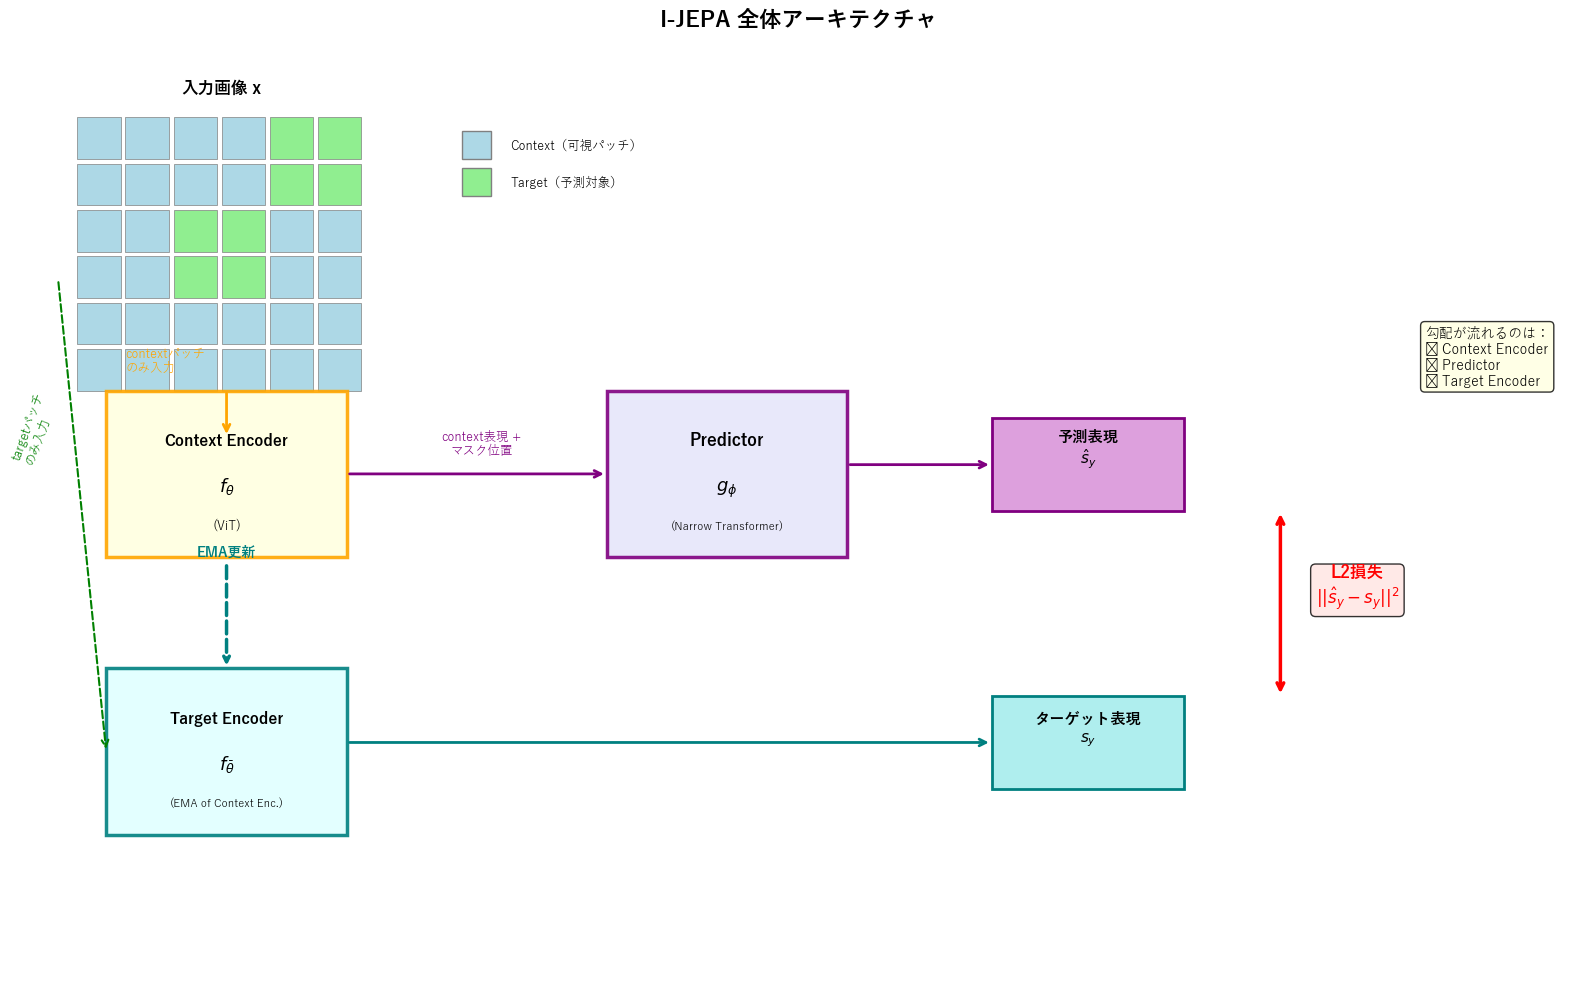

In [4]:
# ============================================================
# I-JEPA 全体アーキテクチャ図
# ============================================================

def visualize_ijepa_architecture():
    """I-JEPAの完全なアーキテクチャを図示"""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # --- 入力画像 ---
    ax.text(2.0, 9.5, '入力画像 x', ha='center', fontsize=12, fontweight='bold')

    # 画像グリッド
    for i in range(6):
        for j in range(6):
            x_pos = 0.5 + j * 0.5
            y_pos = 8.8 - i * 0.5
            # コンテキスト = 青、ターゲット = 緑、マスク = グレー
            if (i >= 2 and i <= 3 and j >= 2 and j <= 3):
                color = 'lightgreen'  # ターゲットブロック1
            elif (i >= 0 and i <= 1 and j >= 4 and j <= 5):
                color = 'lightgreen'  # ターゲットブロック2
            else:
                color = 'lightblue'  # コンテキスト
            rect = plt.Rectangle((x_pos, y_pos), 0.45, 0.45,
                                  facecolor=color, edgecolor='gray', linewidth=0.5)
            ax.add_patch(rect)

    # 凡例
    ax.add_patch(plt.Rectangle((4.5, 8.8), 0.3, 0.3, facecolor='lightblue', edgecolor='gray'))
    ax.text(5.0, 8.95, 'Context（可視パッチ）', fontsize=9, va='center')
    ax.add_patch(plt.Rectangle((4.5, 8.4), 0.3, 0.3, facecolor='lightgreen', edgecolor='gray'))
    ax.text(5.0, 8.55, 'Target（予測対象）', fontsize=9, va='center')

    # --- Context Encoder ---
    rect_ce = plt.Rectangle((0.8, 4.5), 2.5, 1.8, facecolor='lightyellow',
                             edgecolor='orange', linewidth=2.5, alpha=0.9)
    ax.add_patch(rect_ce)
    ax.text(2.05, 5.7, 'Context Encoder', ha='center', fontsize=11, fontweight='bold')
    ax.text(2.05, 5.2, '$f_\\theta$', ha='center', fontsize=13)
    ax.text(2.05, 4.8, '(ViT)', ha='center', fontsize=9, style='italic')

    # 矢印: 画像 → Context Encoder
    ax.annotate('', xy=(2.05, 6.3), xytext=(2.05, 5.8),
                arrowprops=dict(arrowstyle='<-', lw=2, color='orange'))
    ax.text(1.0, 6.5, 'contextパッチ\nのみ入力', fontsize=9, color='orange')

    # --- Target Encoder ---
    rect_te = plt.Rectangle((0.8, 1.5), 2.5, 1.8, facecolor='lightcyan',
                             edgecolor='teal', linewidth=2.5, alpha=0.9)
    ax.add_patch(rect_te)
    ax.text(2.05, 2.7, 'Target Encoder', ha='center', fontsize=11, fontweight='bold')
    ax.text(2.05, 2.2, '$f_{\\bar{\\theta}}$', ha='center', fontsize=13)
    ax.text(2.05, 1.8, '(EMA of Context Enc.)', ha='center', fontsize=8, style='italic')

    # EMA矢印
    ax.annotate('EMA更新', xy=(2.05, 3.3), xytext=(2.05, 4.5),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='teal', linestyle='--'),
                ha='center', fontsize=10, color='teal', fontweight='bold')

    # 矢印: 画像 → Target Encoder（targetパッチ）
    ax.annotate('', xy=(0.8, 2.4), xytext=(0.3, 7.5),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='green', linestyle='--'))
    ax.text(-0.2, 5.5, 'targetパッチ\nのみ入力', fontsize=9, color='green', rotation=70)

    # --- Predictor ---
    rect_pr = plt.Rectangle((6.0, 4.5), 2.5, 1.8, facecolor='lavender',
                             edgecolor='purple', linewidth=2.5, alpha=0.9)
    ax.add_patch(rect_pr)
    ax.text(7.25, 5.7, 'Predictor', ha='center', fontsize=12, fontweight='bold')
    ax.text(7.25, 5.2, '$g_\\phi$', ha='center', fontsize=13)
    ax.text(7.25, 4.8, '(Narrow Transformer)', ha='center', fontsize=8, style='italic')

    # 矢印: Context Encoder → Predictor
    ax.annotate('', xy=(6.0, 5.4), xytext=(3.3, 5.4),
                arrowprops=dict(arrowstyle='->', lw=2, color='purple'))
    ax.text(4.7, 5.6, 'context表現 +\nマスク位置', ha='center', fontsize=9, color='purple')

    # --- 予測と比較 ---
    # 予測された表現
    rect_pred = plt.Rectangle((10.0, 5.0), 2.0, 1.0, facecolor='plum',
                               edgecolor='purple', linewidth=2)
    ax.add_patch(rect_pred)
    ax.text(11.0, 5.5, '予測表現\n$\\hat{s}_y$', ha='center', fontsize=11, fontweight='bold')
    ax.annotate('', xy=(10.0, 5.5), xytext=(8.5, 5.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='purple'))

    # ターゲット表現
    rect_tgt = plt.Rectangle((10.0, 2.0), 2.0, 1.0, facecolor='paleturquoise',
                              edgecolor='teal', linewidth=2)
    ax.add_patch(rect_tgt)
    ax.text(11.0, 2.5, 'ターゲット表現\n$s_y$', ha='center', fontsize=11, fontweight='bold')
    ax.annotate('', xy=(10.0, 2.5), xytext=(3.3, 2.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='teal'))

    # L2損失
    ax.annotate('', xy=(13.0, 5.0), xytext=(13.0, 3.0),
                arrowprops=dict(arrowstyle='<->', lw=2.5, color='red'))
    ax.text(13.8, 4.0, 'L2損失\n$||\\hat{s}_y - s_y||^2$', ha='center', fontsize=12,
            fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.8))

    # 勾配の流れ
    ax.text(14.5, 7.0, '勾配が流れるのは：\n✅ Context Encoder\n✅ Predictor\n❌ Target Encoder',
            fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.set_title('I-JEPA 全体アーキテクチャ', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

visualize_ijepa_architecture()

<a id="section3"></a>
## 3. MultiBlockMasking の実装

### 📊 非対称マスキング戦略

I-JEPAのマスキングは、MAEとは根本的に異なります：

| 特徴 | MAE | I-JEPA |
|------|-----|--------|
| マスク形状 | ランダムパッチ | 矩形ブロック |
| マスク率 | 75% | 約15%（ターゲットのみ） |
| コンテキスト | 残り25%のパッチ | 画像の約85% |
| ターゲット数 | 全マスクパッチ | 複数の小ブロック（4個程度） |

**Multi-Block Masking**: 複数の矩形ブロック（ターゲット）をランダムに配置し、
残りの全パッチ（コンテキスト）からターゲットの表現を予測します。

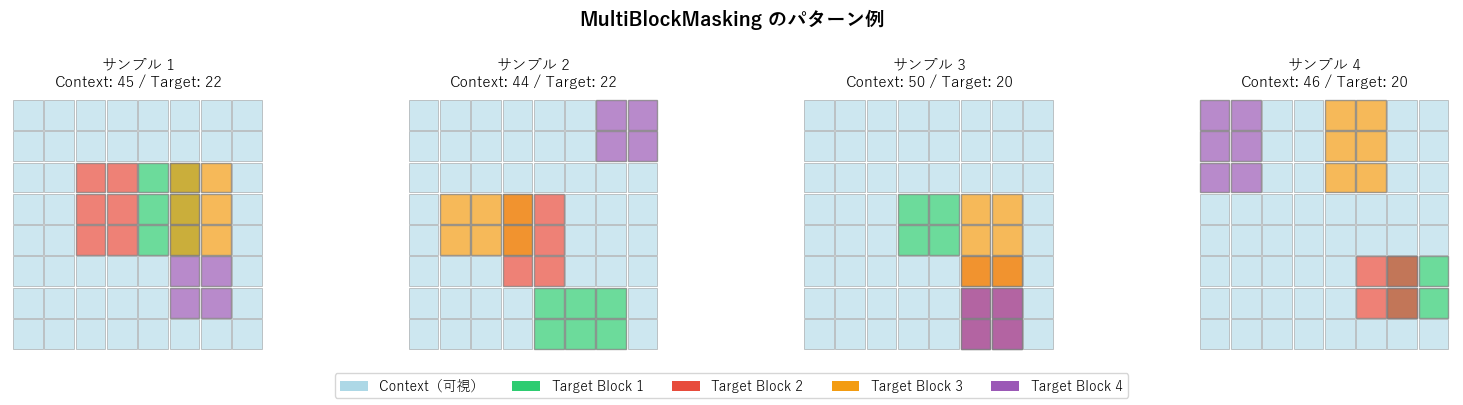

コンテキスト比率の統計（100回の平均）:
  平均: 68.7%
  範囲: 56.2% ~ 81.2%


In [5]:
# ============================================================
# MultiBlockMasking の実装
# ============================================================

class MultiBlockMasking:
    """I-JEPA用のマルチブロックマスキング

    画像をパッチのグリッドに分割し、複数の矩形ブロックを
    ターゲットとしてマスクする。残りがコンテキストとなる。

    Args:
        grid_size: パッチグリッドのサイズ (H_patches, W_patches)
        num_targets: ターゲットブロックの数
        target_aspect_ratio: ターゲットブロックのアスペクト比の範囲
        target_scale: ターゲットブロックの面積割合の範囲
    """

    def __init__(self, grid_size=8, num_targets=4,
                 target_aspect_ratio=(0.75, 1.5),
                 target_scale=(0.15, 0.2)):
        self.grid_size = grid_size
        self.num_targets = num_targets
        self.target_aspect_ratio = target_aspect_ratio
        self.target_scale = target_scale

    def __call__(self):
        """マスクを生成する

        Returns:
            context_mask: (grid_size * grid_size,) bool配列 - Trueがコンテキスト
            target_masks: list of (grid_size * grid_size,) bool配列 - 各ターゲットブロック
        """
        G = self.grid_size
        total_patches = G * G

        # 全パッチはまずコンテキストとして設定
        all_target = np.zeros((G, G), dtype=bool)
        target_masks = []

        for _ in range(self.num_targets):
            # ターゲットブロックのサイズを決定
            scale = np.random.uniform(*self.target_scale)
            aspect = np.random.uniform(*self.target_aspect_ratio)

            # ブロックの面積（パッチ数）
            num_patches = int(total_patches * scale)
            # ブロックの高さと幅
            h = max(1, int(np.sqrt(num_patches * aspect)))
            w = max(1, int(np.sqrt(num_patches / aspect)))
            h = min(h, G - 1)
            w = min(w, G - 1)

            # ブロックの開始位置をランダムに選択
            top = np.random.randint(0, G - h + 1)
            left = np.random.randint(0, G - w + 1)

            # ターゲットマスクを作成
            target = np.zeros((G, G), dtype=bool)
            target[top:top+h, left:left+w] = True
            target_masks.append(target.flatten())

            # 全ターゲットに追加
            all_target[top:top+h, left:left+w] = True

        # コンテキストはターゲットでないパッチ
        context_mask = ~all_target.flatten()

        return context_mask, target_masks

    def visualize(self, n_samples=4):
        """マスキングパターンを可視化"""
        fig, axes = plt.subplots(1, n_samples, figsize=(4 * n_samples, 4))
        if n_samples == 1:
            axes = [axes]

        colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

        for ax_idx, ax in enumerate(axes):
            np.random.seed(ax_idx * 10 + 42)
            context_mask, target_masks = self()
            G = self.grid_size

            # グリッドを描画
            for i in range(G):
                for j in range(G):
                    idx = i * G + j
                    if context_mask[idx]:
                        color = 'lightblue'
                        alpha = 0.6
                    else:
                        color = 'white'
                        alpha = 0.3
                    rect = plt.Rectangle((j, G - 1 - i), 0.95, 0.95,
                                          facecolor=color, edgecolor='gray',
                                          alpha=alpha, linewidth=0.5)
                    ax.add_patch(rect)

            # ターゲットブロックを色分けして描画
            for t_idx, t_mask in enumerate(target_masks):
                c = colors[t_idx % len(colors)]
                for i in range(G):
                    for j in range(G):
                        idx = i * G + j
                        if t_mask[idx]:
                            rect = plt.Rectangle((j, G - 1 - i), 0.95, 0.95,
                                                  facecolor=c, edgecolor='gray',
                                                  alpha=0.7, linewidth=1)
                            ax.add_patch(rect)

            n_context = context_mask.sum()
            n_target = sum(m.sum() for m in target_masks)
            ax.set_xlim(-0.1, G + 0.1)
            ax.set_ylim(-0.1, G + 0.1)
            ax.set_aspect('equal')
            ax.set_title(f'サンプル {ax_idx+1}\n'
                         f'Context: {n_context} / Target: {n_target}',
                         fontsize=11)
            ax.axis('off')

        from matplotlib.patches import Patch
        legend_items = [Patch(facecolor='lightblue', label='Context（可視）')]
        for i in range(min(self.num_targets, len(colors))):
            legend_items.append(Patch(facecolor=colors[i], label=f'Target Block {i+1}'))
        fig.legend(handles=legend_items, loc='lower center', ncol=5, fontsize=10)

        plt.suptitle('MultiBlockMasking のパターン例', fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])
        plt.show()

# テスト
masking = MultiBlockMasking(grid_size=8, num_targets=4,
                             target_scale=(0.10, 0.18))
masking.visualize(n_samples=4)

# 統計を表示
context_ratios = []
for _ in range(100):
    c, t = masking()
    context_ratios.append(c.sum() / len(c))
print(f"コンテキスト比率の統計（100回の平均）:")
print(f"  平均: {np.mean(context_ratios):.1%}")
print(f"  範囲: {np.min(context_ratios):.1%} ~ {np.max(context_ratios):.1%}")

<a id="section4"></a>
## 4. エンコーダとプレディクタの実装

### 📊 3つのネットワーク

I-JEPAの3つのネットワークを実装します。
教育目的で、アーキテクチャは小規模に保ちます：

| コンポーネント | 次元 | 層数 | ヘッド数 | 備考 |
|---------------|------|------|---------|------|
| Context Encoder | 64 | 3 | 4 | ViT-like |
| Target Encoder | 64 | 3 | 4 | Context Encoderと同じ構造（EMA） |
| Predictor | 32 | 2 | 4 | **狭い**Transformer |

**Predictorが狭い理由**: Predictorは表現の変換のみを担当し、
入力の意味理解はEncoderが担当します。Predictorが大きすぎると、
Context Encoderが怠けてしまう（情報をPredictorに任せてしまう）問題があります。

In [6]:
# ============================================================
# パッチ埋め込み層
# ============================================================

class PatchEmbed(nn.Module):
    """画像をパッチに分割して埋め込む

    Args:
        img_size: 入力画像のサイズ
        patch_size: パッチのサイズ
        in_channels: 入力チャンネル数
        embed_dim: 埋め込み次元
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size  # パッチグリッドのサイズ
        self.num_patches = self.grid_size ** 2   # 総パッチ数

        # 畳み込みでパッチ埋め込み
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

        # 位置埋め込み（学習可能）
        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, embed_dim) * 0.02
        )

    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) 入力画像
        Returns:
            (B, N, D) パッチ埋め込み列  N=num_patches, D=embed_dim
        """
        B = x.shape[0]
        # (B, C, H, W) → (B, D, G, G) → (B, D, N) → (B, N, D)
        x = self.proj(x)  # (B, D, G, G)
        x = x.flatten(2).transpose(1, 2)  # (B, N, D)
        x = x + self.pos_embed  # 位置情報を加算
        return x

# テスト
patch_embed = PatchEmbed(img_size=32, patch_size=4, in_channels=1, embed_dim=64)
x = torch.randn(2, 1, 32, 32)
out = patch_embed(x)
print(f"PatchEmbed: {x.shape} → {out.shape}")
print(f"  グリッドサイズ: {patch_embed.grid_size}x{patch_embed.grid_size}")
print(f"  パッチ数: {patch_embed.num_patches}")

PatchEmbed: torch.Size([2, 1, 32, 32]) → torch.Size([2, 64, 64])
  グリッドサイズ: 8x8
  パッチ数: 64


In [7]:
# ============================================================
# Transformerブロック
# ============================================================

class TransformerBlock(nn.Module):
    """標準的なTransformerブロック（Pre-Norm）

    LayerNorm → MultiHeadAttention → 残差
    LayerNorm → FFN → 残差
    """

    def __init__(self, dim, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        """x: (B, N, D) → (B, N, D)"""
        # Self-Attention + 残差
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        # FFN + 残差
        x = x + self.mlp(self.norm2(x))
        return x

# テスト
block = TransformerBlock(dim=64, num_heads=4)
x = torch.randn(2, 64, 64)  # (B, N, D)
print(f"TransformerBlock: {x.shape} → {block(x).shape}")
print(f"  パラメータ数: {sum(p.numel() for p in block.parameters()):,}")

TransformerBlock: torch.Size([2, 64, 64]) → torch.Size([2, 64, 64])
  パラメータ数: 49,984


In [8]:
# ============================================================
# Context Encoder
# ============================================================

class ContextEncoder(nn.Module):
    """コンテキストエンコーダ: 可視パッチをエンコードする

    PatchEmbed + Transformer layers
    マスクされていない（可視の）パッチのみを処理する。
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=1,
                 embed_dim=64, depth=3, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim

    def forward(self, x, context_mask=None):
        """
        Args:
            x: (B, C, H, W) 入力画像
            context_mask: (N,) bool配列 - Trueがコンテキストパッチ
        Returns:
            (B, N_context, D) コンテキストパッチの表現
        """
        # パッチ埋め込み
        tokens = self.patch_embed(x)  # (B, N, D)

        # コンテキストパッチのみ選択
        if context_mask is not None:
            # context_maskをtorch.Tensorに変換
            if isinstance(context_mask, np.ndarray):
                context_mask = torch.from_numpy(context_mask)
            tokens = tokens[:, context_mask]  # (B, N_context, D)

        # Transformerブロック
        for block in self.blocks:
            tokens = block(tokens)

        tokens = self.norm(tokens)
        return tokens

# テスト
context_enc = ContextEncoder(img_size=32, patch_size=4, in_channels=1,
                              embed_dim=64, depth=3, num_heads=4)
x = torch.randn(2, 1, 32, 32)
np.random.seed(42)
ctx_mask, tgt_masks = masking()

out = context_enc(x, ctx_mask)
print(f"ContextEncoder:")
print(f"  入力: {x.shape}")
print(f"  コンテキストマスク: {ctx_mask.sum()}/{len(ctx_mask)} パッチ")
print(f"  出力: {out.shape}")
print(f"  パラメータ数: {sum(p.numel() for p in context_enc.parameters()):,}")

ContextEncoder:
  入力: torch.Size([2, 1, 32, 32])
  コンテキストマスク: 45/64 パッチ
  出力: torch.Size([2, 45, 64])
  パラメータ数: 155,264


In [9]:
# ============================================================
# Predictor（予測器）
# ============================================================

class Predictor(nn.Module):
    """予測器: コンテキスト表現からターゲット表現を予測

    Context Encoderよりも狭い（小さい次元の）Transformer。
    マスク位置トークンをクエリとして、コンテキスト表現から
    ターゲット位置の表現を予測する。

    Args:
        context_dim: Context Encoderの出力次元
        pred_dim: Predictorの内部次元（context_dimより小さい）
        num_patches: 総パッチ数
        depth: Transformerの層数
        num_heads: Attentionのヘッド数
    """

    def __init__(self, context_dim=64, pred_dim=32, num_patches=64,
                 depth=2, num_heads=4):
        super().__init__()
        self.context_dim = context_dim
        self.pred_dim = pred_dim

        # 次元を変換（context_dim → pred_dim）
        self.input_proj = nn.Linear(context_dim, pred_dim)

        # マスクトークン（学習可能）: ターゲット位置の初期表現
        self.mask_token = nn.Parameter(torch.randn(1, 1, pred_dim) * 0.02)

        # 位置埋め込み（全パッチ分）
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches, pred_dim) * 0.02
        )

        # Transformerブロック
        self.blocks = nn.ModuleList([
            TransformerBlock(pred_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(pred_dim)

        # 出力射影（pred_dim → context_dim）
        self.output_proj = nn.Linear(pred_dim, context_dim)

    def forward(self, context_tokens, context_mask, target_mask):
        """
        Args:
            context_tokens: (B, N_context, context_dim) コンテキスト表現
            context_mask: (N,) bool配列 - コンテキストパッチの位置
            target_mask: (N,) bool配列 - ターゲットパッチの位置
        Returns:
            (B, N_target, context_dim) ターゲットの予測表現
        """
        B = context_tokens.shape[0]
        N = len(context_mask)  # 総パッチ数

        if isinstance(context_mask, np.ndarray):
            context_mask = torch.from_numpy(context_mask)
        if isinstance(target_mask, np.ndarray):
            target_mask = torch.from_numpy(target_mask)

        N_context = context_mask.sum().item()
        N_target = target_mask.sum().item()

        # コンテキスト表現をpred_dimに射影
        ctx = self.input_proj(context_tokens)  # (B, N_context, pred_dim)

        # マスクトークンを生成（ターゲット位置用）
        mask_tokens = self.mask_token.expand(B, N_target, -1)  # (B, N_target, pred_dim)

        # 全パッチ位置にトークンを配置
        tokens = torch.zeros(B, N, self.pred_dim, device=context_tokens.device)

        # コンテキスト位置にコンテキスト表現を配置
        ctx_indices = torch.where(context_mask)[0]
        tokens[:, ctx_indices] = ctx

        # ターゲット位置にマスクトークンを配置
        tgt_indices = torch.where(target_mask)[0]
        tokens[:, tgt_indices] = mask_tokens

        # 位置埋め込みを加算
        tokens = tokens + self.pos_embed[:, :N]

        # Transformerブロック
        for block in self.blocks:
            tokens = block(tokens)

        tokens = self.norm(tokens)

        # ターゲット位置のトークンのみ取り出し
        target_preds = tokens[:, tgt_indices]  # (B, N_target, pred_dim)

        # 元の次元に射影
        target_preds = self.output_proj(target_preds)  # (B, N_target, context_dim)

        return target_preds

# テスト
predictor = Predictor(context_dim=64, pred_dim=32, num_patches=64,
                       depth=2, num_heads=4)

np.random.seed(42)
ctx_mask, tgt_masks = masking()
# 全ターゲットを結合
combined_tgt = np.zeros(64, dtype=bool)
for m in tgt_masks:
    combined_tgt |= m

ctx_tokens = torch.randn(2, ctx_mask.sum(), 64)
pred_out = predictor(ctx_tokens, ctx_mask, combined_tgt)

print(f"Predictor:")
print(f"  コンテキスト入力: {ctx_tokens.shape}")
print(f"  ターゲットマスク: {combined_tgt.sum()} パッチ")
print(f"  予測出力: {pred_out.shape}")
print(f"  パラメータ数: {sum(p.numel() for p in predictor.parameters()):,}")

Predictor:
  コンテキスト入力: torch.Size([2, 45, 64])
  ターゲットマスク: 19 パッチ
  予測出力: torch.Size([2, 19, 64])
  パラメータ数: 31,744


### 💡 Predictorの設計ポイント

Predictorのアーキテクチャには重要な設計判断があります：

1. **狭い次元（pred_dim < context_dim）**: Predictorの表現力を意図的に制限することで、
   意味的な理解の負担をContext Encoderに押し付けます。

2. **マスクトークン**: ターゲット位置に配置される学習可能なトークンが、
   「ここに何があるか予測してください」というクエリの役割を果たします。

3. **位置埋め込み**: コンテキストとターゲットの**空間的な位置関係**を
   Predictorに伝えることで、「どこの表現を予測すべきか」を学習できます。

<a id="section5"></a>
## 5. EMA更新の実装と理解

### 🤔 なぜEMA更新が必要か？

Target Encoderを通常の勾配降下で更新すると、**表現崩壊**が起こります：
- Context EncoderとTarget Encoderが同じ出力をするように最適化されてしまう
- 全ての入力に対して同じ定数ベクトルを出力する「自明な解」に収束

**EMA（Exponential Moving Average）** はこの問題を防ぎます：

$$\\bar{\\theta} \\leftarrow m \\cdot \\bar{\\theta} + (1 - m) \\cdot \\theta$$

- $\\bar{\\theta}$: Target Encoderのパラメータ
- $\\theta$: Context Encoderのパラメータ
- $m$: モメンタム係数（0.996 ~ 0.999）

Target Encoderは**ゆっくりと**Context Encoderを追従するため、
常に「少し古いが安定した」表現を提供します。
これにより、学習目標が急激に変化しないため、安定した学習が可能になります。

In [10]:
# ============================================================
# EMA更新の実装
# ============================================================

@torch.no_grad()
def ema_update(target_params, context_params, momentum=0.996):
    """Target Encoderのパラメータをコンテキストエンコーダの
    指数移動平均で更新する

    target_param = momentum * target_param + (1 - momentum) * context_param

    Args:
        target_params: Target Encoderのパラメータイテレータ
        context_params: Context Encoderのパラメータイテレータ
        momentum: EMAモメンタム係数（0に近いと追従が速い、1に近いと遅い）
    """
    for target_p, context_p in zip(target_params, context_params):
        target_p.data.mul_(momentum).add_(context_p.data, alpha=1.0 - momentum)

# EMAの動作確認
print("="*60)
print("EMA更新の動作確認")
print("="*60)

# 簡単な例
torch.manual_seed(42)
context_model = nn.Linear(4, 4)
target_model = copy.deepcopy(context_model)  # 初期状態は同じ

# コンテキストモデルのパラメータを変更（学習をシミュレート）
with torch.no_grad():
    for p in context_model.parameters():
        p.add_(torch.randn_like(p) * 0.5)

print("\n更新前:")
print(f"  Context weight[0]: {context_model.weight.data[0, :2].tolist()}")
print(f"  Target weight[0]:  {target_model.weight.data[0, :2].tolist()}")

# EMA更新
ema_update(target_model.parameters(), context_model.parameters(), momentum=0.996)

print("\n更新後 (momentum=0.996):")
print(f"  Context weight[0]: {context_model.weight.data[0, :2].tolist()}")
print(f"  Target weight[0]:  {target_model.weight.data[0, :2].tolist()}")

diff = (target_model.weight.data - context_model.weight.data).abs().mean()
print(f"\n  パラメータの平均差: {diff:.4f}")
print("  → Target EncoderはContext Encoderにゆっくり近づく")

EMA更新の動作確認

更新前:
  Context weight[0]: [0.0032036900520324707, 0.9541627764701843]
  Target weight[0]:  [0.3822692632675171, 0.4150039553642273]

更新後 (momentum=0.996):
  Context weight[0]: [0.0032036900520324707, 0.9541627764701843]
  Target weight[0]:  [0.3807530105113983, 0.41716060042381287]

  パラメータの平均差: 0.2991
  → Target EncoderはContext Encoderにゆっくり近づく


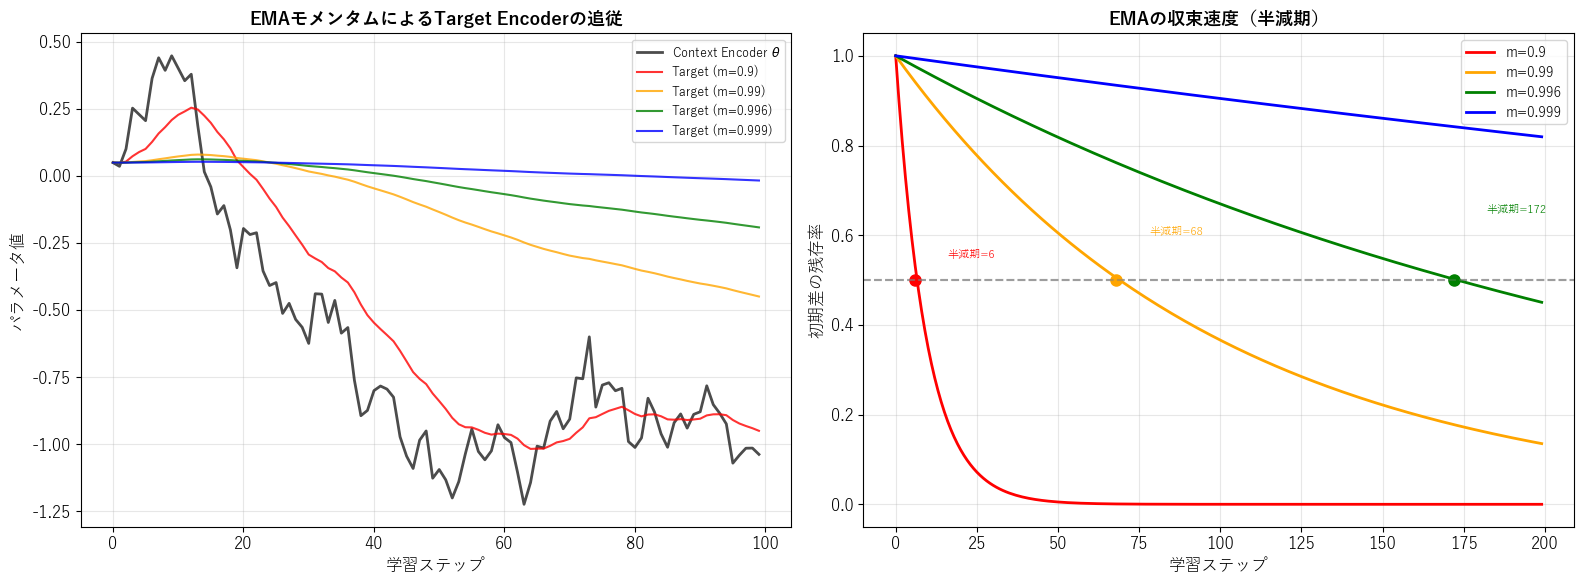

観察ポイント:
- モメンタムが大きいほどTarget Encoderの変化は滑らか
- m=0.996 が I-JEPA の典型的な設定
- 半減期: m=0.996 → 約173ステップで差が半減


In [11]:
# ============================================================
# EMAモメンタムの効果を可視化
# ============================================================

def visualize_ema_trajectory():
    """異なるモメンタム係数でのEMA軌跡を可視化"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- 左: 1Dでの軌跡 ---
    ax = axes[0]
    T_steps = 100
    np.random.seed(42)

    # コンテキストパラメータの変化（ランダムウォーク）
    context_values = np.cumsum(np.random.randn(T_steps) * 0.1)

    momentums = [0.9, 0.99, 0.996, 0.999]
    colors = ['red', 'orange', 'green', 'blue']

    ax.plot(context_values, 'k-', linewidth=2, label='Context Encoder $\\theta$', alpha=0.7)

    for m, c in zip(momentums, colors):
        target_values = np.zeros(T_steps)
        target_values[0] = context_values[0]
        for t in range(1, T_steps):
            target_values[t] = m * target_values[t-1] + (1-m) * context_values[t]
        ax.plot(target_values, color=c, linewidth=1.5,
                label=f'Target (m={m})', alpha=0.8)

    ax.set_xlabel('学習ステップ', fontsize=12)
    ax.set_ylabel('パラメータ値', fontsize=12)
    ax.set_title('EMAモメンタムによるTarget Encoderの追従', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- 右: 収束速度 ---
    ax = axes[1]
    steps = np.arange(200)
    for m, c in zip(momentums, colors):
        # 初期差 1.0 が EMA でどれだけ残るか
        remaining = m ** steps
        ax.plot(steps, remaining, color=c, linewidth=2, label=f'm={m}')
        # 半減期
        half_life = int(np.log(0.5) / np.log(m)) if m < 1 else float('inf')
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
        if half_life < 200:
            ax.plot(half_life, 0.5, 'o', color=c, markersize=8)
            ax.annotate(f'半減期={half_life}', xy=(half_life, 0.5),
                        xytext=(half_life + 10, 0.55 + momentums.index(m)*0.05),
                        fontsize=8, color=c)

    ax.set_xlabel('学習ステップ', fontsize=12)
    ax.set_ylabel('初期差の残存率', fontsize=12)
    ax.set_title('EMAの収束速度（半減期）', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

    print("観察ポイント:")
    print("- モメンタムが大きいほどTarget Encoderの変化は滑らか")
    print("- m=0.996 が I-JEPA の典型的な設定")
    print("- 半減期: m=0.996 → 約173ステップで差が半減")

visualize_ema_trajectory()

<a id="section6"></a>
## 6. I-JEPA訓練ループ

### 📊 訓練の全体フロー

```
1. 入力画像 x をサンプリング
2. MultiBlockMasking でコンテキストとターゲットを決定
3. Context Encoder: コンテキストパッチの表現を計算
4. Target Encoder: ターゲットパッチの表現を計算（勾配なし）
5. Predictor: コンテキスト表現からターゲット表現を予測
6. 損失: 予測表現とターゲット表現のL2距離
7. Context Encoder と Predictor を勾配で更新
8. Target Encoder を EMA で更新
```

In [12]:
# ============================================================
# I-JEPA モデル（統合クラス）
# ============================================================

class IJEPA(nn.Module):
    """I-JEPA: Image-based Joint Embedding Predictive Architecture

    全コンポーネントを統合したモデルクラス。

    Args:
        img_size: 入力画像サイズ
        patch_size: パッチサイズ
        in_channels: 入力チャンネル数
        embed_dim: Encoder の埋め込み次元
        pred_dim: Predictor の内部次元
        enc_depth: Encoder の Transformer 層数
        pred_depth: Predictor の Transformer 層数
        num_heads: Attention ヘッド数
        ema_momentum: EMA モメンタム
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=1,
                 embed_dim=64, pred_dim=32,
                 enc_depth=3, pred_depth=2, num_heads=4,
                 ema_momentum=0.996):
        super().__init__()

        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.ema_momentum = ema_momentum

        # Context Encoder
        self.context_encoder = ContextEncoder(
            img_size=img_size, patch_size=patch_size,
            in_channels=in_channels, embed_dim=embed_dim,
            depth=enc_depth, num_heads=num_heads
        )

        # Target Encoder（Context Encoderのコピー）
        self.target_encoder = copy.deepcopy(self.context_encoder)
        # Target Encoderの勾配を無効化
        for p in self.target_encoder.parameters():
            p.requires_grad = False

        # Predictor
        self.predictor = Predictor(
            context_dim=embed_dim, pred_dim=pred_dim,
            num_patches=self.num_patches,
            depth=pred_depth, num_heads=num_heads
        )

        # マスキング
        self.masking = MultiBlockMasking(
            grid_size=self.grid_size, num_targets=4,
            target_scale=(0.10, 0.18)
        )

    @torch.no_grad()
    def update_target_encoder(self):
        """Target EncoderをEMAで更新"""
        ema_update(
            self.target_encoder.parameters(),
            self.context_encoder.parameters(),
            momentum=self.ema_momentum
        )

    def forward(self, x):
        """訓練時の順伝播

        Args:
            x: (B, C, H, W) 入力画像バッチ
        Returns:
            loss: スカラー損失値
            info: 追加情報の辞書
        """
        B = x.shape[0]

        # 1. マスク生成
        context_mask, target_masks = self.masking()

        # ターゲットマスクを結合
        combined_target = np.zeros(self.num_patches, dtype=bool)
        for m in target_masks:
            combined_target |= m

        # 2. Context Encoder: 可視パッチをエンコード
        context_tokens = self.context_encoder(x, context_mask)
        # shape: (B, N_context, embed_dim)

        # 3. Target Encoder: ターゲットパッチをエンコード（勾配なし）
        with torch.no_grad():
            # 全パッチをエンコードしてからターゲット位置を取り出す
            all_tokens = self.target_encoder(x, context_mask=None)
            # shape: (B, N, embed_dim)
            tgt_indices = torch.from_numpy(np.where(combined_target)[0])
            target_tokens = all_tokens[:, tgt_indices]
            # shape: (B, N_target, embed_dim)

        # 4. Predictor: コンテキスト表現からターゲット表現を予測
        predicted_tokens = self.predictor(
            context_tokens, context_mask, combined_target
        )
        # shape: (B, N_target, embed_dim)

        # 5. 損失計算: L2距離
        # ターゲット表現は勾配を切断（stop gradient）
        loss = F.mse_loss(predicted_tokens, target_tokens.detach())

        info = {
            'n_context': int(context_mask.sum()),
            'n_target': int(combined_target.sum()),
            'pred_norm': predicted_tokens.norm(dim=-1).mean().item(),
            'target_norm': target_tokens.norm(dim=-1).mean().item(),
        }

        return loss, info

# テスト
model = IJEPA(img_size=32, patch_size=4, in_channels=1,
              embed_dim=64, pred_dim=32,
              enc_depth=3, pred_depth=2, num_heads=4)

x = torch.randn(4, 1, 32, 32)
loss, info = model(x)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_all = sum(p.numel() for p in model.parameters())

print(f"I-JEPA モデル:")
print(f"  入力: {x.shape}")
print(f"  損失: {loss.item():.4f}")
print(f"  コンテキスト: {info['n_context']} パッチ")
print(f"  ターゲット: {info['n_target']} パッチ")
print(f"  予測ノルム: {info['pred_norm']:.3f}")
print(f"  ターゲットノルム: {info['target_norm']:.3f}")
print(f"  学習可能パラメータ: {total_params:,}")
print(f"  全パラメータ: {total_all:,}")

I-JEPA モデル:
  入力: torch.Size([4, 1, 32, 32])
  損失: 1.2530
  コンテキスト: 46 パッチ
  ターゲット: 18 パッチ
  予測ノルム: 4.275
  ターゲットノルム: 8.000
  学習可能パラメータ: 187,008
  全パラメータ: 342,272


データセット: FashionMNIST
サブセットサイズ: 5000
バッチサイズ: 64
バッチ数: 78


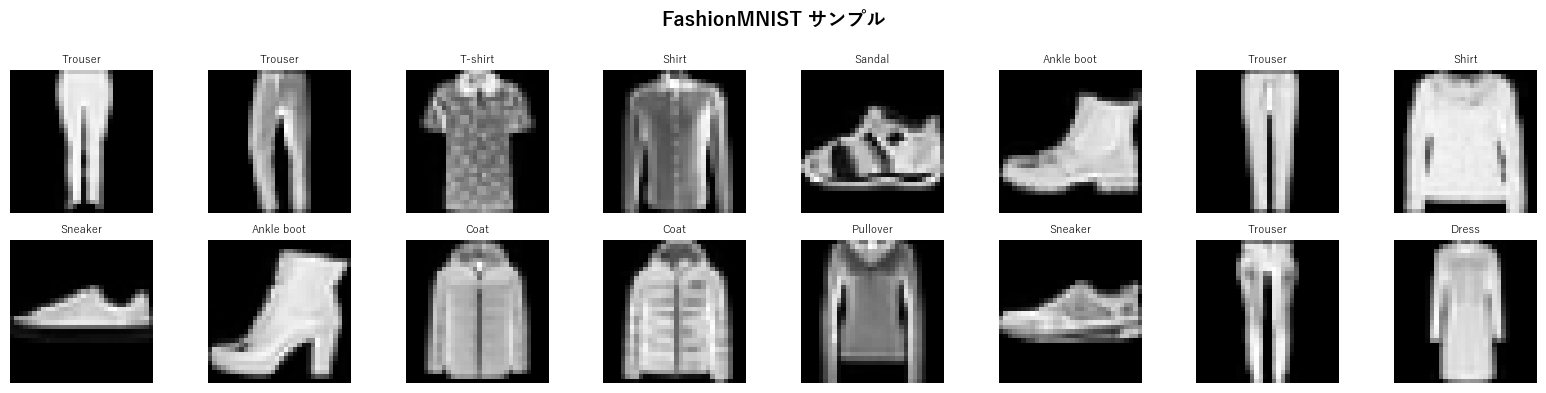

In [13]:
# ============================================================
# データセットの準備と訓練
# ============================================================

# FashionMNISTを使用（小さなサブセット）
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# データセットのダウンロード
full_dataset = torchvision.datasets.FashionMNIST(
    root='/tmp/data', train=True, download=True, transform=transform
)

# 教育目的で小さなサブセットを使用
subset_size = 5000
indices = torch.randperm(len(full_dataset))[:subset_size]
subset = torch.utils.data.Subset(full_dataset, indices)

train_loader = DataLoader(subset, batch_size=64, shuffle=True, drop_last=True)

print(f"データセット: FashionMNIST")
print(f"サブセットサイズ: {subset_size}")
print(f"バッチサイズ: 64")
print(f"バッチ数: {len(train_loader)}")

# サンプル表示
sample_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(sample_batch[0][i, 0].numpy(), cmap='gray')
    ax.set_title(class_names[sample_batch[1][i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('FashionMNIST サンプル', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# I-JEPA 訓練ループ
# ============================================================

# モデル初期化
torch.manual_seed(42)
ijepa = IJEPA(
    img_size=32, patch_size=4, in_channels=1,
    embed_dim=64, pred_dim=32,
    enc_depth=3, pred_depth=2, num_heads=4,
    ema_momentum=0.996
).to(device)

# Context Encoder と Predictor のみ最適化
optimizer = torch.optim.AdamW(
    list(ijepa.context_encoder.parameters()) + list(ijepa.predictor.parameters()),
    lr=1e-3, weight_decay=0.05
)

# 学習率スケジューラ（Cosine Annealing）
NUM_EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

print(f"訓練設定:")
print(f"  エポック数: {NUM_EPOCHS}")
print(f"  学習率: 1e-3 → 1e-5 (Cosine)")
print(f"  EMAモメンタム: 0.996")
print(f"  デバイス: {device}")
print(f"  学習可能パラメータ: {sum(p.numel() for p in ijepa.parameters() if p.requires_grad):,}")
print()

# 訓練ループ
train_losses = []
train_infos = []

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    epoch_infos = []

    ijepa.train()
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        # 順伝播
        loss, info = ijepa(images)

        # 逆伝播
        optimizer.zero_grad()
        loss.backward()
        # 勾配クリッピング
        torch.nn.utils.clip_grad_norm_(ijepa.parameters(), max_norm=1.0)
        optimizer.step()

        # Target Encoder の EMA 更新
        ijepa.update_target_encoder()

        epoch_losses.append(loss.item())
        epoch_infos.append(info)

    scheduler.step()

    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    train_infos.append(epoch_infos[-1])

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"LR: {lr_now:.2e} | "
              f"pred_norm: {epoch_infos[-1]['pred_norm']:.3f} | "
              f"tgt_norm: {epoch_infos[-1]['target_norm']:.3f}")

print("\n✅ I-JEPA 訓練完了")

訓練設定:
  エポック数: 20
  学習率: 1e-3 → 1e-5 (Cosine)
  EMAモメンタム: 0.996
  デバイス: cpu
  学習可能パラメータ: 187,008

  Epoch   1/20 | Loss: 0.4786 | LR: 9.94e-04 | pred_norm: 6.693 | tgt_norm: 8.002
  Epoch   5/20 | Loss: 0.2691 | LR: 8.55e-04 | pred_norm: 6.525 | tgt_norm: 7.972
  Epoch  10/20 | Loss: 0.2384 | LR: 5.05e-04 | pred_norm: 7.008 | tgt_norm: 7.860
  Epoch  15/20 | Loss: 0.2226 | LR: 1.55e-04 | pred_norm: 6.494 | tgt_norm: 7.792
  Epoch  20/20 | Loss: 0.2315 | LR: 1.00e-05 | pred_norm: 6.448 | tgt_norm: 7.751

✅ I-JEPA 訓練完了


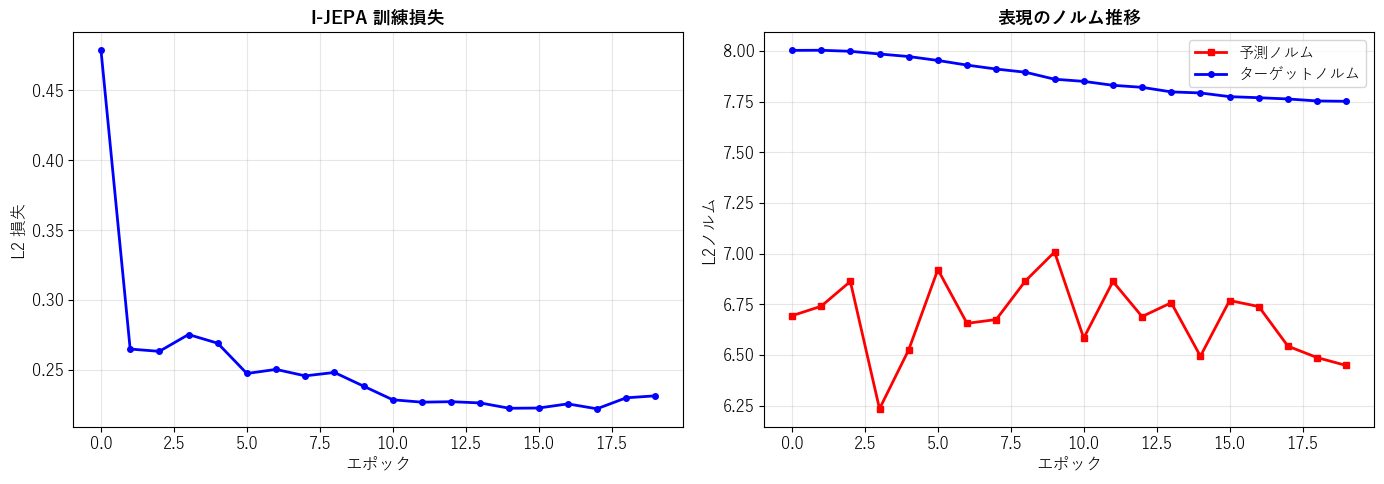

観察ポイント:
- 損失が着実に減少していれば、表現学習が進んでいる
- ノルムが崩壊（0に近づく）していなければ、EMAが正常に機能している
- 予測ノルムとターゲットノルムが近い値であれば良い兆候


In [15]:
# ============================================================
# 訓練結果の可視化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 損失曲線
ax = axes[0]
ax.plot(train_losses, 'b-', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('エポック', fontsize=12)
ax.set_ylabel('L2 損失', fontsize=12)
ax.set_title('I-JEPA 訓練損失', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 表現のノルム
ax = axes[1]
pred_norms = [info['pred_norm'] for info in train_infos]
tgt_norms = [info['target_norm'] for info in train_infos]
ax.plot(pred_norms, 'r-', linewidth=2, label='予測ノルム', marker='s', markersize=4)
ax.plot(tgt_norms, 'b-', linewidth=2, label='ターゲットノルム', marker='o', markersize=4)
ax.set_xlabel('エポック', fontsize=12)
ax.set_ylabel('L2ノルム', fontsize=12)
ax.set_title('表現のノルム推移', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("観察ポイント:")
print("- 損失が着実に減少していれば、表現学習が進んでいる")
print("- ノルムが崩壊（0に近づく）していなければ、EMAが正常に機能している")
print("- 予測ノルムとターゲットノルムが近い値であれば良い兆候")

<a id="section7"></a>
## 7. 学習済み表現の評価

### 📊 表現の品質をどう測るか？

自己教師あり学習で学んだ表現の品質を評価する方法：

1. **t-SNE可視化**: 学習済みエンコーダで特徴を抽出し、2次元に射影して視覚的に確認
2. **Linear Probe**: 学習済みエンコーダを凍結し、線形分類器のみを訓練して分類精度を測定
3. **比較実験**: ランダム初期化との比較

In [16]:
# ============================================================
# 学習済み表現の抽出
# ============================================================

@torch.no_grad()
def extract_features(encoder, dataloader, device, max_samples=2000):
    """エンコーダを使って特徴量を抽出する

    Args:
        encoder: 学習済みエンコーダ
        dataloader: データローダー
        device: デバイス
        max_samples: 最大サンプル数
    Returns:
        features: (N, D) 特徴量
        labels: (N,) ラベル
    """
    encoder.eval()
    all_features = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)

        # 全パッチをエンコード（マスクなし）
        tokens = encoder(images, context_mask=None)  # (B, N, D)

        # 全パッチの平均をとって画像レベルの特徴に
        features = tokens.mean(dim=1)  # (B, D)

        all_features.append(features.cpu())
        all_labels.append(labels)

        if sum(f.shape[0] for f in all_features) >= max_samples:
            break

    features = torch.cat(all_features, dim=0)[:max_samples]
    labels = torch.cat(all_labels, dim=0)[:max_samples]

    return features.numpy(), labels.numpy()

# I-JEPA で学習した表現を抽出
features_jepa, labels_all = extract_features(
    ijepa.context_encoder, train_loader, device, max_samples=2000
)

# ランダム初期化のエンコーダで表現を抽出（比較用）
torch.manual_seed(0)
random_encoder = ContextEncoder(
    img_size=32, patch_size=4, in_channels=1,
    embed_dim=64, depth=3, num_heads=4
).to(device)

features_random, _ = extract_features(
    random_encoder, train_loader, device, max_samples=2000
)

print(f"抽出した特徴量:")
print(f"  I-JEPA: {features_jepa.shape}")
print(f"  ランダム: {features_random.shape}")
print(f"  ラベル: {labels_all.shape} (クラス: {np.unique(labels_all)})")

抽出した特徴量:
  I-JEPA: (2000, 64)
  ランダム: (2000, 64)
  ラベル: (2000,) (クラス: [0 1 2 3 4 5 6 7 8 9])


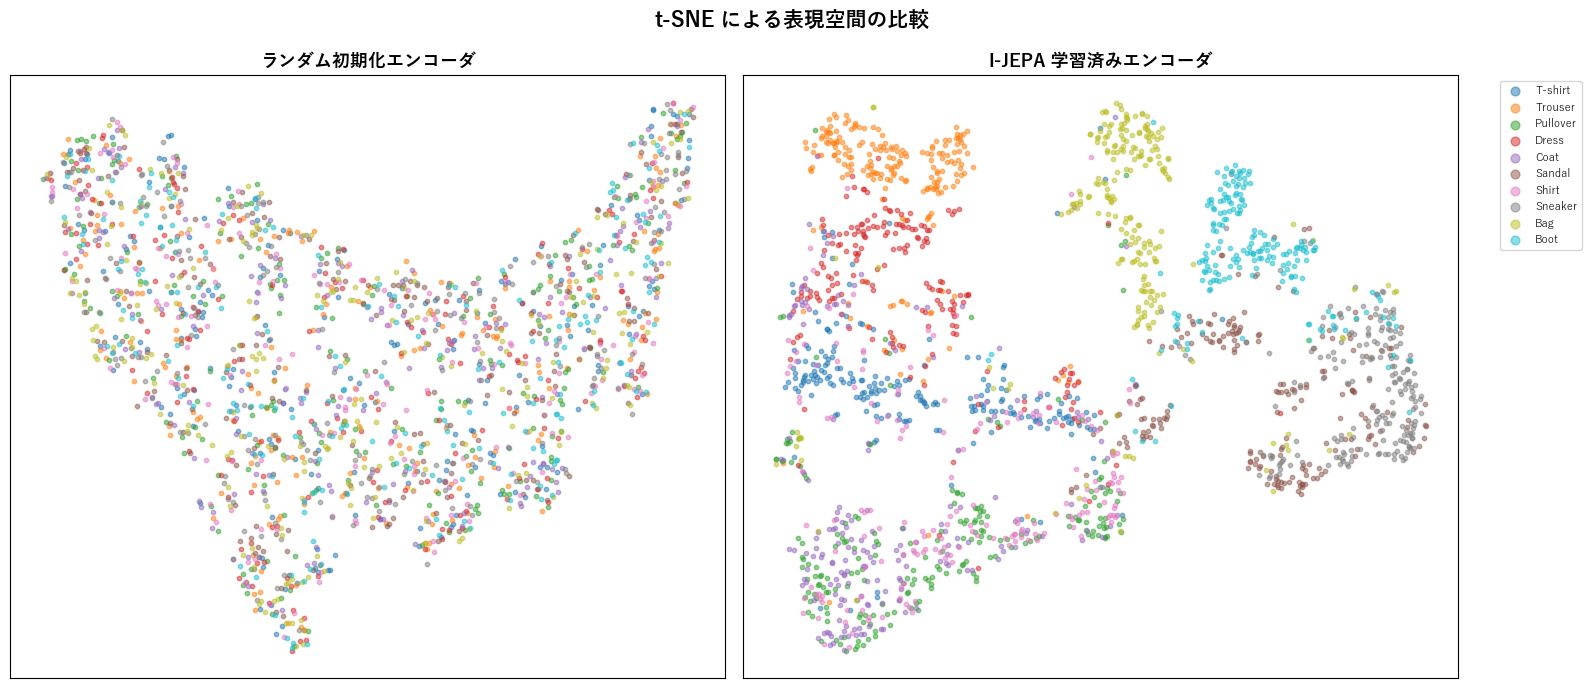

観察ポイント:
- ランダム初期化: クラスが混在し、構造がない
- I-JEPA学習後: 同じクラスのサンプルがクラスタを形成する傾向
- これはラベルを一切使わずに学習した結果！


In [17]:
# ============================================================
# t-SNE による表現の可視化
# ============================================================

from sklearn.manifold import TSNE

def plot_tsne(features, labels, title, ax, class_names=None):
    """t-SNE で特徴量を2次元に射影して可視化"""
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)

    n_classes = len(np.unique(labels))
    cmap = plt.cm.tab10

    for c in range(n_classes):
        mask = labels == c
        label = class_names[c] if class_names else str(c)
        ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                   c=[cmap(c / n_classes)], alpha=0.5, s=10, label=label)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_tsne(features_random, labels_all, 'ランダム初期化エンコーダ', axes[0], class_names)
plot_tsne(features_jepa, labels_all, 'I-JEPA 学習済みエンコーダ', axes[1], class_names)

axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, markerscale=2)

plt.suptitle('t-SNE による表現空間の比較', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("観察ポイント:")
print("- ランダム初期化: クラスが混在し、構造がない")
print("- I-JEPA学習後: 同じクラスのサンプルがクラスタを形成する傾向")
print("- これはラベルを一切使わずに学習した結果！")

In [18]:
# ============================================================
# Linear Probe（線形評価）
# ============================================================

def linear_probe(features_train, labels_train, features_test, labels_test):
    """学習済み特徴量の上に線形分類器を訓練して評価

    Args:
        features_train: (N_train, D) 訓練特徴量
        labels_train: (N_train,) 訓練ラベル
        features_test: (N_test, D) テスト特徴量
        labels_test: (N_test,) テストラベル
    Returns:
        accuracy: テスト精度
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    # 特徴量の標準化
    scaler = StandardScaler()
    features_train_scaled = scaler.fit_transform(features_train)
    features_test_scaled = scaler.transform(features_test)

    # ロジスティック回帰
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    clf.fit(features_train_scaled, labels_train)

    accuracy = clf.score(features_test_scaled, labels_test)
    return accuracy

# テストデータの準備
test_dataset = torchvision.datasets.FashionMNIST(
    root='/tmp/data', train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# テスト特徴量の抽出
features_jepa_test, labels_test = extract_features(
    ijepa.context_encoder, test_loader, device, max_samples=2000
)
features_random_test, _ = extract_features(
    random_encoder, test_loader, device, max_samples=2000
)

# Linear Probe実行
acc_random = linear_probe(features_random, labels_all,
                           features_random_test, labels_test)
acc_jepa = linear_probe(features_jepa, labels_all,
                         features_jepa_test, labels_test)

print("="*60)
print("Linear Probe 結果（テスト精度）")
print("="*60)
print(f"  ランダム初期化:  {acc_random:.1%}")
print(f"  I-JEPA 学習済み: {acc_jepa:.1%}")
print(f"  差分:           +{acc_jepa - acc_random:.1%}")
print()
print("→ ラベルなしの自己教師あり学習だけで、")
print("  意味的に有用な表現が学習できていることを確認")

Linear Probe 結果（テスト精度）
  ランダム初期化:  10.1%
  I-JEPA 学習済み: 73.2%
  差分:           +63.1%

→ ラベルなしの自己教師あり学習だけで、
  意味的に有用な表現が学習できていることを確認


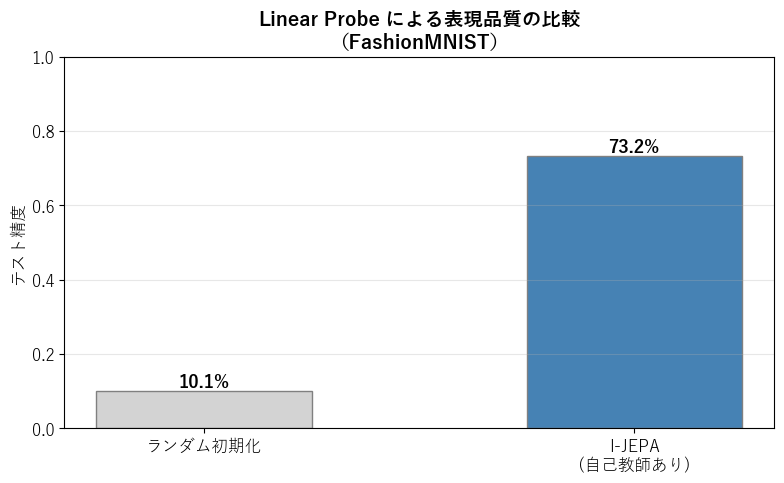

In [19]:
# ============================================================
# Linear Probe 精度の比較（棒グラフ）
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

methods = ['ランダム初期化', 'I-JEPA\n(自己教師あり)']
accuracies = [acc_random, acc_jepa]
colors = ['lightgray', 'steelblue']

bars = ax.bar(methods, accuracies, color=colors, edgecolor='gray', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('テスト精度', fontsize=12)
ax.set_title('Linear Probe による表現品質の比較\n（FashionMNIST）', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

<a id="section8"></a>
## 8. V-JEPAへの拡張（概念）

### 📊 画像から動画へ: I-JEPA → V-JEPA

I-JEPAの原理を動画に拡張したのが **V-JEPA（Video JEPA）** です。

| 特徴 | I-JEPA | V-JEPA |
|------|--------|--------|
| 入力 | 画像 (H, W) | 動画 (T, H, W) |
| マスク | 空間的な矩形ブロック | **時空間的な**チューブ |
| 予測 | 空間的に離れた表現 | **時間的に離れた**フレームの表現 |
| 応用 | 画像理解 | 動画理解、行動認識 |

### 🔑 V-JEPAの核心

V-JEPAでは、動画の一部のフレーム（コンテキスト）を見て、
**未来のフレームの表現**を予測します。

重要なのは、未来のフレームの**ピクセルを予測するのではなく**、
**埋め込みベクトルを予測する**点です。

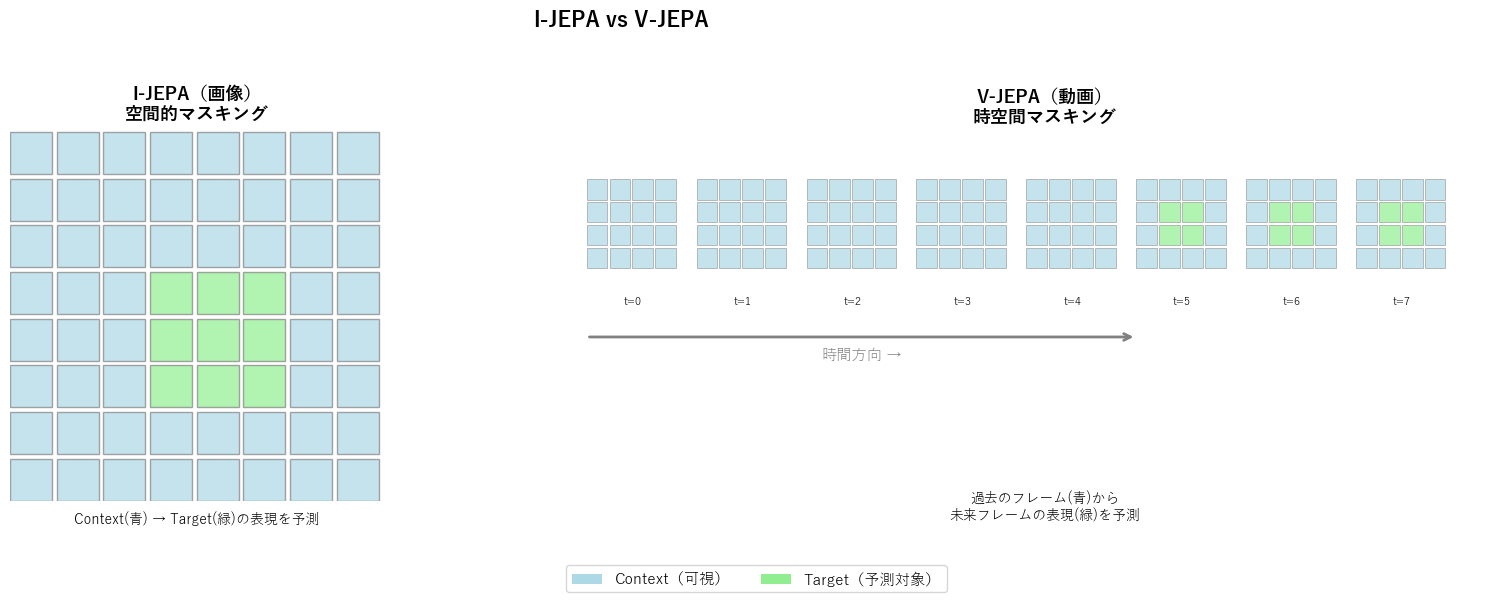

In [20]:
# ============================================================
# V-JEPA の概念図
# ============================================================

def visualize_vjepa_concept():
    """V-JEPAの時空間マスキングの概念図"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- 左: I-JEPA（画像） ---
    ax = axes[0]
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('I-JEPA（画像）\n空間的マスキング', fontsize=13, fontweight='bold')

    for i in range(8):
        for j in range(8):
            if (i >= 3 and i <= 5 and j >= 3 and j <= 5):
                color = 'lightgreen'
            else:
                color = 'lightblue'
            rect = plt.Rectangle((j, 7 - i), 0.9, 0.9,
                                  facecolor=color, edgecolor='gray', alpha=0.7)
            ax.add_patch(rect)

    ax.text(4, -0.5, 'Context(青) → Target(緑)の表現を予測',
            ha='center', fontsize=10)

    # --- 右: V-JEPA（動画） ---
    ax = axes[1]
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('V-JEPA（動画）\n時空間マスキング', fontsize=13, fontweight='bold')

    # 8フレーム × 4×4パッチ
    for t in range(8):
        offset_x = t * 2.4
        for i in range(4):
            for j in range(4):
                # 後半フレーム（t>=5）の中央をターゲット
                if t >= 5 and i >= 1 and i <= 2 and j >= 1 and j <= 2:
                    color = 'lightgreen'
                else:
                    color = 'lightblue'
                rect = plt.Rectangle((offset_x + j * 0.5, 6.5 - i * 0.5),
                                      0.45, 0.45,
                                      facecolor=color, edgecolor='gray',
                                      alpha=0.7, linewidth=0.5)
                ax.add_patch(rect)
        ax.text(offset_x + 1.0, 4.2, f't={t}', ha='center', fontsize=8)

    # フレームの区切り矢印
    ax.annotate('', xy=(12, 3.5), xytext=(0, 3.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    ax.text(6, 3.0, '時間方向 →', ha='center', fontsize=11, color='gray')

    ax.text(10, -0.5, '過去のフレーム(青)から\n未来フレームの表現(緑)を予測',
            ha='center', fontsize=10)

    from matplotlib.patches import Patch
    legend_items = [
        Patch(facecolor='lightblue', label='Context（可視）'),
        Patch(facecolor='lightgreen', label='Target（予測対象）'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=2, fontsize=11)

    plt.suptitle('I-JEPA vs V-JEPA', fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

visualize_vjepa_concept()

### 💡 なぜピクセルレベルの動画予測はダメなのか？

動画の未来フレームをピクセルレベルで予測することには、根本的な問題があります：

1. **不確実性**: 未来は確定的ではない。人がコインを投げたとき、
   表か裏かはピクセルレベルでは予測不可能だが、「コインが空中にある」ことは予測できる。

2. **高次元性**: 動画のピクセル空間は非常に高次元で、
   些細なディテール（光の反射、テクスチャのブレなど）に計算資源が浪費される。

3. **意味のない変動**: 風で揺れる木の葉のピクセル変化を予測することに意味はない。
   重要なのは「木がある」「風が吹いている」という抽象的な理解。

V-JEPAは**埋め込み空間で予測**することで、これらの問題を回避します：
- 予測不可能なディテールは埋め込みでは平滑化される
- 意味的に重要な情報のみを捉えた表現を学習する
- これこそが**世界モデル**への道筋

> **Yann LeCun**: 「世界の内部モデルを構築するためには、
> 予測不可能な情報を無視し、予測可能な抽象的な表現のレベルで
> 推論する能力が必要である。」

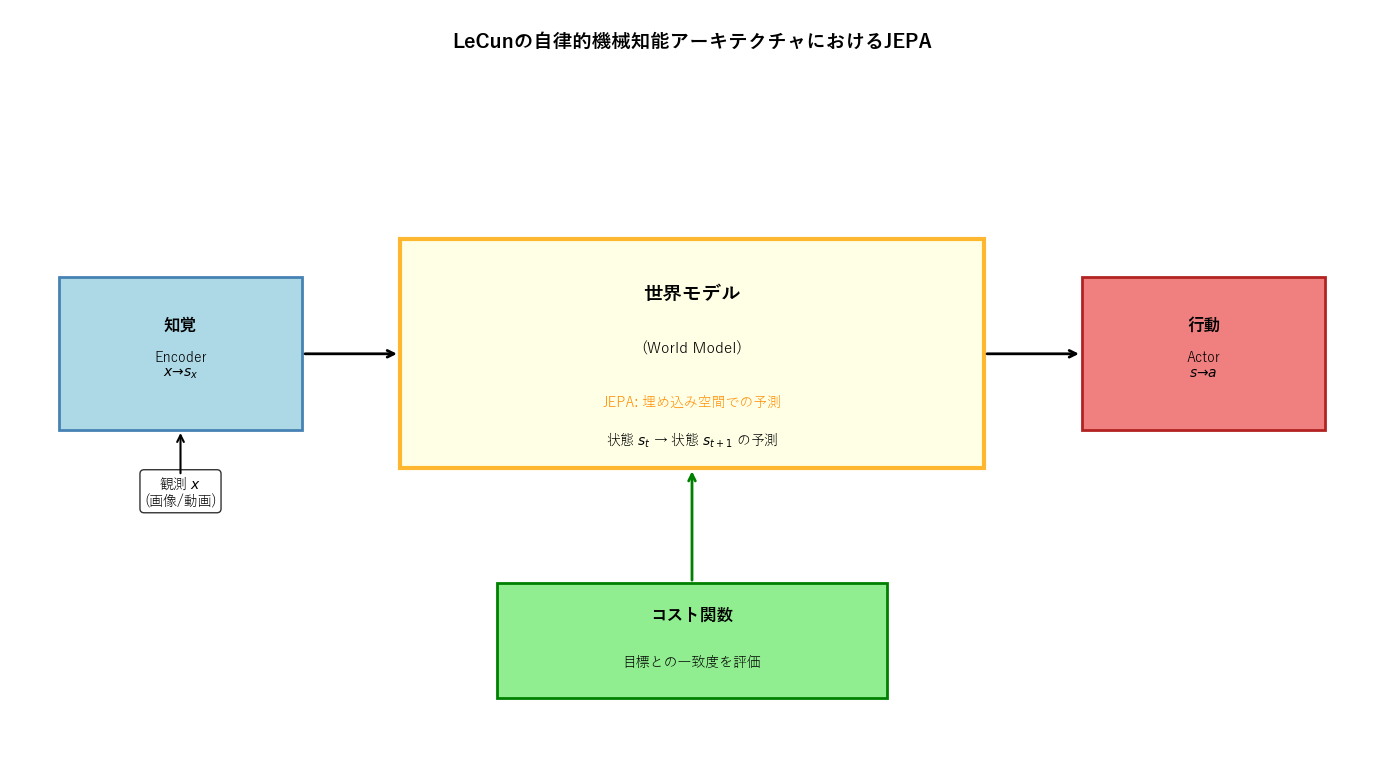

JEPAの位置づけ:
- 知覚モジュール: 観測を埋め込み空間にエンコード（= Encoder）
- 世界モデル: 埋め込み空間での状態遷移を予測（= JEPA）
- 行動モジュール: 予測された未来の状態に基づいて行動を決定
- コスト関数: 目標状態との一致度を評価


In [21]:
# ============================================================
# JEPAと世界モデルの関係図
# ============================================================

def visualize_jepa_in_world_models():
    """JEPAが世界モデルの中でどのように位置づけられるかを図示"""
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # タイトル
    ax.text(7, 9.5, 'LeCunの自律的機械知能アーキテクチャにおけるJEPA',
            ha='center', fontsize=14, fontweight='bold')

    # 世界モデル（中央）
    rect = plt.Rectangle((4, 4), 6, 3, facecolor='lightyellow',
                          edgecolor='orange', linewidth=3, alpha=0.8)
    ax.add_patch(rect)
    ax.text(7, 6.2, '世界モデル', ha='center', fontsize=14, fontweight='bold')
    ax.text(7, 5.5, '(World Model)', ha='center', fontsize=11, style='italic')
    ax.text(7, 4.8, 'JEPA: 埋め込み空間での予測', ha='center', fontsize=10,
            color='darkorange')
    ax.text(7, 4.3, '状態 $s_t$ → 状態 $s_{t+1}$ の予測', ha='center', fontsize=10)

    # 知覚モジュール
    rect_p = plt.Rectangle((0.5, 4.5), 2.5, 2, facecolor='lightblue',
                            edgecolor='steelblue', linewidth=2)
    ax.add_patch(rect_p)
    ax.text(1.75, 5.8, '知覚', ha='center', fontsize=12, fontweight='bold')
    ax.text(1.75, 5.2, 'Encoder\n$x → s_x$', ha='center', fontsize=10)
    ax.annotate('', xy=(4, 5.5), xytext=(3, 5.5),
                arrowprops=dict(arrowstyle='->', lw=2))

    # 行動モジュール
    rect_a = plt.Rectangle((11, 4.5), 2.5, 2, facecolor='lightcoral',
                            edgecolor='firebrick', linewidth=2)
    ax.add_patch(rect_a)
    ax.text(12.25, 5.8, '行動', ha='center', fontsize=12, fontweight='bold')
    ax.text(12.25, 5.2, 'Actor\n$s → a$', ha='center', fontsize=10)
    ax.annotate('', xy=(11, 5.5), xytext=(10, 5.5),
                arrowprops=dict(arrowstyle='->', lw=2))

    # コスト・報酬
    rect_c = plt.Rectangle((5, 1), 4, 1.5, facecolor='lightgreen',
                            edgecolor='green', linewidth=2)
    ax.add_patch(rect_c)
    ax.text(7, 2.0, 'コスト関数', ha='center', fontsize=12, fontweight='bold')
    ax.text(7, 1.4, '目標との一致度を評価', ha='center', fontsize=10)
    ax.annotate('', xy=(7, 2.5), xytext=(7, 4.0),
                arrowprops=dict(arrowstyle='<-', lw=2, color='green'))

    # 観測
    ax.text(1.75, 3.5, '観測 $x$\n(画像/動画)', ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.annotate('', xy=(1.75, 4.5), xytext=(1.75, 3.9),
                arrowprops=dict(arrowstyle='->', lw=1.5))

    plt.tight_layout()
    plt.show()

    print("JEPAの位置づけ:")
    print("- 知覚モジュール: 観測を埋め込み空間にエンコード（= Encoder）")
    print("- 世界モデル: 埋め込み空間での状態遷移を予測（= JEPA）")
    print("- 行動モジュール: 予測された未来の状態に基づいて行動を決定")
    print("- コスト関数: 目標状態との一致度を評価")

visualize_jepa_in_world_models()

<a id="summary"></a>
## 9. まとめとよくあるエラー

### 🎯 このノートブックで学んだこと

**JEPAの思想**
- MAE（ピクセル再構成）は低レベルのディテールに注力してしまう
- JEPA は埋め込み空間で予測することで意味的な表現を効率的に学習
- Yann LeCun の「自律的機械知能への道」の中核概念

**I-JEPAのアーキテクチャ**
- Context Encoder: 可視パッチをエンコード（勾配で学習）
- Target Encoder: ターゲットパッチをエンコード（EMAで更新）
- Predictor: コンテキスト表現からターゲット表現を予測（狭いTransformer）

**重要な設計判断**
- 非対称マスキング: 大きなコンテキスト、小さなターゲット
- EMA更新: 表現崩壊を防止
- 狭いPredictor: 意味理解の負担をEncoderに集中

**V-JEPAへの拡張**
- 画像→動画: 空間的マスク→時空間的マスク
- 未来のフレームの表現を予測
- ピクセル予測より本質的な動画理解

### 📊 チートシート

| コンポーネント | 更新方法 | 入力 | 出力 |
|---------------|---------|------|------|
| Context Encoder | 勾配降下 | 可視パッチ | コンテキスト表現 |
| Target Encoder | EMA | ターゲットパッチ | ターゲット表現（正解） |
| Predictor | 勾配降下 | コンテキスト表現 + 位置 | 予測表現 |

### ⚠️ よくあるエラー

#### エラー #1: 表現崩壊（Representation Collapse）

```python
# ❌ Target Encoderも勾配で更新してしまう
optimizer = Adam(list(context_enc.parameters()) +
                 list(target_enc.parameters()) +
                 list(predictor.parameters()))
# → 全ての入力に対して同じベクトルを出力する自明な解に収束

# ✅ Target Encoderは勾配を流さず、EMAのみで更新
for p in target_enc.parameters():
    p.requires_grad = False

optimizer = Adam(list(context_enc.parameters()) +
                 list(predictor.parameters()))
# 学習ステップ後に:
ema_update(target_enc.parameters(), context_enc.parameters(), momentum=0.996)
```

#### エラー #2: Predictorが大きすぎる

```python
# ❌ Predictorの次元がEncoderと同じ
predictor = Predictor(context_dim=256, pred_dim=256, depth=6)
# → PredictorがContext Encoderの代わりに意味理解を担当してしまう

# ✅ Predictorは狭く浅くする
predictor = Predictor(context_dim=256, pred_dim=64, depth=2)
# → 意味理解はContext Encoderが担当
```

#### エラー #3: マスク率の設定ミス

```python
# ❌ ターゲットが大きすぎる（コンテキストが少なすぎる）
masking = MultiBlockMasking(target_scale=(0.4, 0.6))
# → コンテキスト情報が不足し、予測が困難

# ✅ 小さなターゲット、大きなコンテキスト
masking = MultiBlockMasking(target_scale=(0.10, 0.18))
# → 豊富なコンテキストから意味的な予測が可能
```

<a id="quiz"></a>
## 🎓 自己評価クイズ

### Q1: MAEとJEPAの最も本質的な違いは何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: MAEは**ピクセル空間**でマスク部分を再構成しますが、
JEPAは**埋め込み空間**でマスク部分の表現を予測します。

この違いにより、JEPAはテクスチャなどの低レベルディテールではなく、
物体の形状や意味関係といった高レベルの意味的情報を学習できます。

</details>

---

### Q2: Target EncoderをEMAで更新する理由は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: **表現崩壊（Representation Collapse）を防止する**ためです。

Target Encoderを勾配で直接更新すると、Context EncoderとTarget Encoderが
協調して全ての入力に対して同じ定数ベクトルを出力する自明な解に収束します。
EMAにより、Target Encoderは「少し古いが安定した」表現を提供し、
学習目標が急激に変化しないようにします。

</details>

---

### Q3: Predictorの次元をContext Encoderより狭くする理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: Predictorの表現力を意図的に制限することで、
**意味的な理解の負担をContext Encoderに集中させる**ためです。

Predictorが大きすぎると、Context Encoderが怠けて
生の入力情報をそのまま渡し、Predictorが全ての推論を担当してしまいます。
Predictorを狭くすることで、Context Encoderが入力の意味を
しっかりと圧縮・理解するように促します。

</details>

---

### Q4: I-JEPAの非対称マスキングはMAEとどう違いますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 以下の点で異なります：

1. **マスク率**: MAEは75%をマスク、I-JEPAは約15%のみをターゲットに
2. **マスク形状**: MAEはランダムなパッチ単位、I-JEPAは矩形ブロック単位
3. **ターゲット数**: MAEは全マスクパッチを再構成、I-JEPAは複数の小ブロックのみ
4. **コンテキストの大きさ**: I-JEPAは画像の大部分（約85%）をコンテキストとして使用

I-JEPAの大きなコンテキストは、意味的な予測を行うための豊富な情報を提供します。

</details>

---

### Q5: V-JEPAが動画のピクセル予測より優れている理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: 3つの理由があります：

1. **不確実性への対処**: 未来は確定的でないため、ピクセルレベルの予測は
   本質的に不可能。埋め込み空間では不確実な詳細が平滑化される。
2. **計算効率**: ピクセル空間は非常に高次元で、些細なディテールに
   計算資源が浪費される。埋め込み空間ははるかに低次元。
3. **意味的な学習**: 風に揺れる木の葉のピクセル変化を予測する代わりに、
   「木がある」「風が吹いている」という抽象的理解を学習できる。

</details>

---

### ✅ 学習チェックリスト

- [ ] MAEとJEPAの違い（ピクセル再構成 vs 埋め込み予測）を説明できた
- [ ] I-JEPAの3つのコンポーネント（Context/Target Encoder, Predictor）を理解した
- [ ] MultiBlockMaskingの非対称マスキング戦略を実装できた
- [ ] EMA更新の仕組みと表現崩壊防止の効果を理解した
- [ ] Linear Probeで学習済み表現の品質を評価できた
- [ ] V-JEPAへの拡張の考え方を説明できた

---

**次のステップ**: 次の章では、JEPAの概念を拡張し、
**行動条件付き世界モデル**（アクションに応じた未来予測）を学びます。
これにより、ロボティクスや強化学習への応用が可能になります。

### 📚 参考文献

1. Assran, M. et al. (2023). "Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture." *CVPR 2023*.
2. LeCun, Y. (2022). "A Path Towards Autonomous Machine Intelligence." *Meta AI Technical Report*.
3. Bardes, A. et al. (2024). "V-JEPA: Latent Video Prediction for Visual Representation Learning." *Meta AI*.
4. He, K. et al. (2022). "Masked Autoencoders Are Scalable Vision Learners." *CVPR 2022*.